# Notebook 03 - Veri Hikayesi ve Is Onerileri

Bu notebook, ilk iki notebookta uretilen veri kesfi ve gorsellestirme bulgularini is odakli bir hikaye akisi icinde toparlar.

## Icindekiler

1. Problem Tanimi ve Yaklasim
2. Veri ve Gorsel Ciktilarin Hazirlanmasi
3. Gorev 1 - Ilce Karsilastirma Analizi
4. Gorev 2 - Musteri Segmentasyonu
5. Gorev 3 - Tahsilat Performansi Analizi
6. Genel Sonuc ve Aksiyon Plani


## 1. Problem Tanimi ve Yaklasim

### Problem Tanimi

Enerji perakende sirketi icin asil soru sadece "hangi ilce daha cok tuketiyor?" degildir. Daha onemli soru sudur: **Hangi musteri ve bolge kombinasyonlari operasyon, tahsilat ve gelir yonetimi acisindan farkli aksiyon gerektiriyor?**

Bu nedenle analiz uc katmanli ele alinmistir:

1. **Bolge katmani:** Hamamozu, Gumushacikoy ve Goynucek arasindaki hacim, musteri profili ve mevsimsellik farklari.
2. **Musteri katmani:** Tuketim seviyesi ve odeme davranisina gore aksiyon alinabilir segmentler.
3. **Tahsilat katmani:** Zamaninda odeme, gec odeme ve kismi odeme davranisinin operasyonel etkisi.

### Ana Hipotezler

1. Ilceler arasindaki farklar sadece musteri sayisindan kaynaklanmaz; hesap sinifi kompozisyonu ve mevsimsellik de tuketimi etkiler.
2. Mesken grubu kayit sayisi acisindan baskin olsa da, sirket icin yuksek tuketim etkisi daha cok sanayi, altyapi, tarimsal faaliyet ve uretici gruplarindan gelir.
3. Zamaninda odeme orani yuksek olsa bile gec odeme bulunan kayitlar nakit akisi ve takip maliyeti acisindan onemli bir risk havuzu olusturur.
4. En etkili aksiyonlar tum musterilere ayni mesajla gitmekten degil, segment bazli farkli tahsilat ve iletisim stratejileri tasarlamaktan gelir.

### Hikaye Catisi

Bu notebookta uc soru cevaplanir:

- **Nerede fark var?** Ilce karsilastirmasi.
- **Kimler farkli davraniyor?** Musteri segmentasyonu.
- **Ne yapmaliyiz?** Tahsilat ve operasyon aksiyonlari.


## 2. Veri ve Gorsel Ciktilarin Hazirlanmasi

Notebook 01 ve Notebook 02 ile uyumlu olacak sekilde veri setleri yuklenir. Notebook 02'de olusturulan grafikler bu notebookta hikaye akisini desteklemek icin kullanilir.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "elektrik_veri.xlsx"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

print("Veri dosyasi:", DATA_PATH)
print("Grafik klasoru:", FIGURES_DIR)


Veri dosyasi: d:\AÇV-CASE2\case_study_02\data\elektrik_veri.xlsx
Grafik klasoru: d:\AÇV-CASE2\case_study_02\outputs\figures


In [2]:
xls = pd.ExcelFile(DATA_PATH)

df_tahsilat = pd.read_excel(xls, sheet_name="Tahsilat")
df_tahsilat_1 = pd.read_excel(xls, sheet_name="Tahsilat 1")
df_hamamozu = pd.read_excel(xls, sheet_name="Tahakkuk")
df_gumushacikoy = pd.read_excel(xls, sheet_name="Tahakkuk 1")
df_goynucek = pd.read_excel(xls, sheet_name="Tahakkuk 2")

tahakkuk_dfs = {
    "Hamamozu": df_hamamozu,
    "Gumushacikoy": df_gumushacikoy,
    "Goynucek": df_goynucek,
}

df_tahakkuk_all = pd.concat(tahakkuk_dfs.values(), ignore_index=True)
hesap_sinifi_col = df_tahakkuk_all.columns[8]

df_tahakkuk_all["mali_yil_donem"] = pd.to_datetime(df_tahakkuk_all["mali_yil_donem"], errors="coerce")
df_tahakkuk_all["donem"] = df_tahakkuk_all["mali_yil_donem"].dt.to_period("M").dt.to_timestamp()
df_tahakkuk_all["yil"] = df_tahakkuk_all["donem"].dt.year
df_tahakkuk_all["ay"] = df_tahakkuk_all["donem"].dt.month
df_tahakkuk_all["ilce"] = df_tahakkuk_all["ilce"].str.strip()
df_tahakkuk_all[hesap_sinifi_col] = df_tahakkuk_all[hesap_sinifi_col].str.strip()

print("Birlesik tahakkuk:", df_tahakkuk_all.shape)
print("Tahsilat:", df_tahsilat.shape)
print("Tahsilat 1:", df_tahsilat_1.shape)


Birlesik tahakkuk: (1185698, 13)
Tahsilat: (636993, 9)
Tahsilat 1: (917632, 22)


In [3]:
# Tahsilat 1 donem ve odeme zamanlamasi hazirligi.
ay_haritasi = {
    "OCK": 1, "SBT": 2, "SUB": 2, "MAR": 3, "NIS": 4, "MAY": 5,
    "HAZ": 6, "TEM": 7, "AGU": 8, "EYL": 9, "EKM": 10,
    "KAS": 11, "KSM": 11, "ARA": 12, "ARL": 12,
}

def sade_turkce(seri):
    return (
        seri.astype("string").str.strip().str.upper()
        .str.replace(chr(350), "S", regex=False)
        .str.replace(chr(286), "G", regex=False)
        .str.replace(chr(220), "U", regex=False)
        .str.replace(chr(214), "O", regex=False)
        .str.replace(chr(304), "I", regex=False)
        .str.replace(chr(199), "C", regex=False)
    )

def donem_to_datetime(seri):
    parcalar = sade_turkce(seri).str.split(expand=True)
    ay = parcalar[0].map(ay_haritasi)
    yil = pd.to_numeric(parcalar[1], errors="coerce")
    return pd.to_datetime({"year": yil, "month": ay, "day": 1}, errors="coerce")

df_tahsilat_1_clean = df_tahsilat_1.copy()
tahsilat1_donem_col = df_tahsilat_1_clean.columns[0]
tahsilat1_ilce_col = df_tahsilat_1_clean.columns[2]
sozlesme_col_tahsilat1 = df_tahsilat_1_clean.columns[3]
hesap_sinifi_col_tahsilat1 = df_tahsilat_1_clean.columns[4]
tahakkuk_tutar_col = df_tahsilat_1_clean.columns[5]
zamaninda_cols = df_tahsilat_1_clean.columns[6:8].tolist()
gec_cols = df_tahsilat_1_clean.columns[8:22].tolist()
odeme_zamani_cols = zamaninda_cols + gec_cols

df_tahsilat_1_clean["donem"] = donem_to_datetime(df_tahsilat_1_clean[tahsilat1_donem_col])
df_tahsilat_1_clean["zamaninda_kayit"] = df_tahsilat_1_clean[zamaninda_cols].notna().any(axis=1)
df_tahsilat_1_clean["gec_kayit"] = df_tahsilat_1_clean[gec_cols].notna().any(axis=1)
df_tahsilat_1_clean[odeme_zamani_cols] = df_tahsilat_1_clean[odeme_zamani_cols].fillna(0)
df_tahsilat_1_clean["zamaninda_tutar"] = df_tahsilat_1_clean[zamaninda_cols].sum(axis=1)
df_tahsilat_1_clean["gec_tutar"] = df_tahsilat_1_clean[gec_cols].sum(axis=1)

print("Tahsilat 1 donem eksik:", df_tahsilat_1_clean["donem"].isna().sum())


Tahsilat 1 donem eksik: 0


## 3. Gorev 1 - Ilce Karsilastirma Analizi

### Problem Tanimi

Uc ilcede tuketim davranisi ayni mi, yoksa musteri hacmi, hesap sinifi profili ve mevsimsellik nedeniyle farklasiyor mu?

### Hipotez

Gumushacikoy, musteri ve kayit hacmi nedeniyle toplamda daha baskin gorunecektir. Ancak kayit basina ortalama tuketim ve hesap sinifi kirilimlari incelendiginde ilceler arasinda daha nitelikli farklar ortaya cikacaktir.


In [4]:
ilce_ozet = (
    df_tahakkuk_all.groupby("ilce")
    .agg(
        kayit_sayisi=("kwh", "size"),
        benzersiz_musteri=("sozlesme_hesap_no", "nunique"),
        ortalama_kwh=("kwh", "mean"),
        medyan_kwh=("kwh", "median"),
        toplam_kwh=("kwh", "sum"),
    )
    .reset_index()
)

ilce_ozet[["ortalama_kwh", "medyan_kwh", "toplam_kwh"]] = ilce_ozet[["ortalama_kwh", "medyan_kwh", "toplam_kwh"]].round(2)
display(ilce_ozet.sort_values("kayit_sayisi", ascending=False))


,ilce,kayit_sayisi,benzersiz_musteri,ortalama_kwh,medyan_kwh,toplam_kwh
1,GÜMÜŞHACIKÖY,765657,18190,97.34,48.31,74526473.58
0,GÖYNÜCEK,295223,7128,89.67,45.09,26472614.19
2,HAMAMÖZÜ,124818,2981,70.87,40.56,8846428.21


### Analiz ve Gorseller

Notebook 02'de uretilen gorseller ilce karsilastirmasini destekler:

![Ilce Musteri Sayisi](../outputs/figures/ilce_musteri_sayisi_horizontal_bar.png)

![Zaman Serisi Paneli](../outputs/figures/zaman_serisi_grafikleri_panel.png)

![Karsilastirma Paneli](../outputs/figures/karsilastirma_grafikleri_panel.png)


### Bulgular

- **Gumushacikoy hacim merkezi:** Hem kayit sayisi hem de benzersiz musteri sayisi acisindan en buyuk ilcedir. Bu nedenle toplam tuketim, toplam tahsilat ve operasyonel is yukunde dogal olarak one cikar.
- **Goynucek daha kucuk ama tuketim seviyesi dikkate deger:** Musteri hacmi Gumushacikoy'den dusuk olsa da ortalama tuketim profili Hamamozu'ne gore daha yuksektir. Bu durum Goynucek'in sadece "kucuk ilce" olarak okunmamasi gerektigini gosterir.
- **Hamamozu dusuk yogunluklu profil:** Hamamozu hem musteri sayisi hem ortalama tuketim acisindan daha dusuk bir profil sergiler. Bu ilce icin ana soru buyume degil, dusuk/seyrek kullanim davranisinin nedenidir.
- **Mevsimsel dalga operasyon sinyali verir:** Yaz aylarinda tuketimde artis gorulmesi, sogutma, tarimsal faaliyetler veya donemsel kullanim etkisine isaret eder. Bu dalga tahsilat ve saha operasyonlarinin da mevsimsel planlanmasi gerektigini gosterir.
- **Hesap sinifi kompozisyonu fark yaratir:** Ilceler arasindaki tuketim farki sadece bolge etkisiyle degil, hangi hesap siniflarinin o ilcede agirlikli olduguyla da aciklanmalidir.

### Ilce Arketipleri

- **Gumushacikoy - Hacim ve operasyon merkezi:** En yuksek musteri/kayit hacmi. Kapasite planlama, tahsilat kanali yonetimi ve dashboard takibi oncelikli.
- **Goynucek - Orta hacimli ama dikkat isteyen tuketim profili:** Daha kucuk musteri tabaninda tuketim seviyesi yuksek kalabiliyor. Hesap sinifi kirilimiyle birlikte izlenmeli.
- **Hamamozu - Dusuk yogunluklu/seyrek kullanim profili:** Dusuk tuketim, bos/az kullanimli abonelik veya mevsimsel kullanim davranisi acisindan incelenmeli.

### Is Onerileri

- Ilce performansi toplam tuketimle degil, **musteri basina**, **kayit basina** ve **hesap sinifi bazli** metriklerle takip edilmelidir.
- Gumushacikoy icin tahsilat kanali kapasitesi ve operasyon is yuku oncelikli planlanmalidir.
- Goynucek icin yuksek tuketime neden olan hesap siniflari ayrica incelenmelidir.
- Hamamozu icin dusuk tuketimli aboneliklerin nedeni arastirilmali; bos abonelik, mevsimsel kullanim veya saya? okuma/faturalama paterni ayrica kontrol edilmelidir.
- Yaz aylarinda tuketim artisi beklenen donemler icin tahsilat hatirlatmalari, saha ekip planlamasi ve nakit akisi tahmini erkene alinmalidir.


## 4. Gorev 2 - Musteri Segmentasyonu

### Problem Tanimi

Musteriler yalnizca tuketim miktarina gore degil, odeme davranislariyla birlikte degerlendirilirse hangi gruplara ayrilabilir?

### Hipotez

Yuksek tuketimli ve duzenli odeme yapan musteriler degerli segmenti, yuksek tuketimli ve gec odeme egilimi olan musteriler ise tahsilat acisindan oncelikli takip edilmesi gereken segmenti olusturacaktir.


In [5]:
# Musteri seviyesinde tuketim ozeti.
musteri_tuketim = (
    df_tahakkuk_all.groupby("sozlesme_hesap_no")
    .agg(
        ilce=("ilce", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        hesap_sinifi=(hesap_sinifi_col, lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        kayit_sayisi=("kwh", "size"),
        toplam_kwh=("kwh", "sum"),
        ortalama_kwh=("kwh", "mean"),
        medyan_kwh=("kwh", "median"),
    )
    .reset_index()
)

# Musteri seviyesinde odeme davranisi.
musteri_odeme = (
    df_tahsilat_1_clean.groupby(sozlesme_col_tahsilat1)
    .agg(
        fatura_sayisi=(tahakkuk_tutar_col, "size"),
        toplam_tahakkuk=(tahakkuk_tutar_col, "sum"),
        zamaninda_oran=("zamaninda_kayit", "mean"),
        gec_oran=("gec_kayit", "mean"),
        gec_tutar=("gec_tutar", "sum"),
    )
    .reset_index()
    .rename(columns={sozlesme_col_tahsilat1: "sozlesme_hesap_no"})
)

musteri_segment = musteri_tuketim.merge(musteri_odeme, on="sozlesme_hesap_no", how="left")
musteri_segment[["fatura_sayisi", "toplam_tahakkuk", "zamaninda_oran", "gec_oran", "gec_tutar"]] = musteri_segment[["fatura_sayisi", "toplam_tahakkuk", "zamaninda_oran", "gec_oran", "gec_tutar"]].fillna(0)

yuksek_tuketim_sinir = musteri_segment["ortalama_kwh"].quantile(0.75)
gec_risk_sinir = 0.30

def segment_ata(row):
    yuksek_tuketim = row["ortalama_kwh"] >= yuksek_tuketim_sinir
    gec_risk = row["gec_oran"] >= gec_risk_sinir
    if yuksek_tuketim and gec_risk:
        return "Yuksek Tuketim - Tahsilat Riski"
    if yuksek_tuketim and not gec_risk:
        return "Yuksek Tuketim - Duzenli Odeme"
    if not yuksek_tuketim and gec_risk:
        return "Standart Tuketim - Gec Odeme Riski"
    return "Standart Tuketim - Duzenli Odeme"

musteri_segment["segment"] = musteri_segment.apply(segment_ata, axis=1)

segment_ozet = (
    musteri_segment.groupby("segment")
    .agg(
        musteri_sayisi=("sozlesme_hesap_no", "nunique"),
        ortalama_kwh=("ortalama_kwh", "mean"),
        toplam_kwh=("toplam_kwh", "sum"),
        ortalama_gec_oran=("gec_oran", "mean"),
        toplam_gec_tutar=("gec_tutar", "sum"),
    )
    .reset_index()
)

segment_ozet[["ortalama_kwh", "toplam_kwh", "ortalama_gec_oran", "toplam_gec_tutar"]] = segment_ozet[["ortalama_kwh", "toplam_kwh", "ortalama_gec_oran", "toplam_gec_tutar"]].round(2)
display(segment_ozet.sort_values("musteri_sayisi", ascending=False))


,segment,musteri_sayisi,ortalama_kwh,toplam_kwh,ortalama_gec_oran,toplam_gec_tutar
0,Standart Tuketim - Duzenli Odeme,13148,31.89,19752933.83,0.06,2406499.29
1,Standart Tuketim - Gec Odeme Riski,8069,28.30,9768819.67,0.64,10695538.03
2,Yuksek Tuketim - Duzenli Odeme,4382,261.12,44503960.87,0.07,8392629.10
3,Yuksek Tuketim - Tahsilat Riski,2691,371.40,35819801.61,0.65,75564920.15


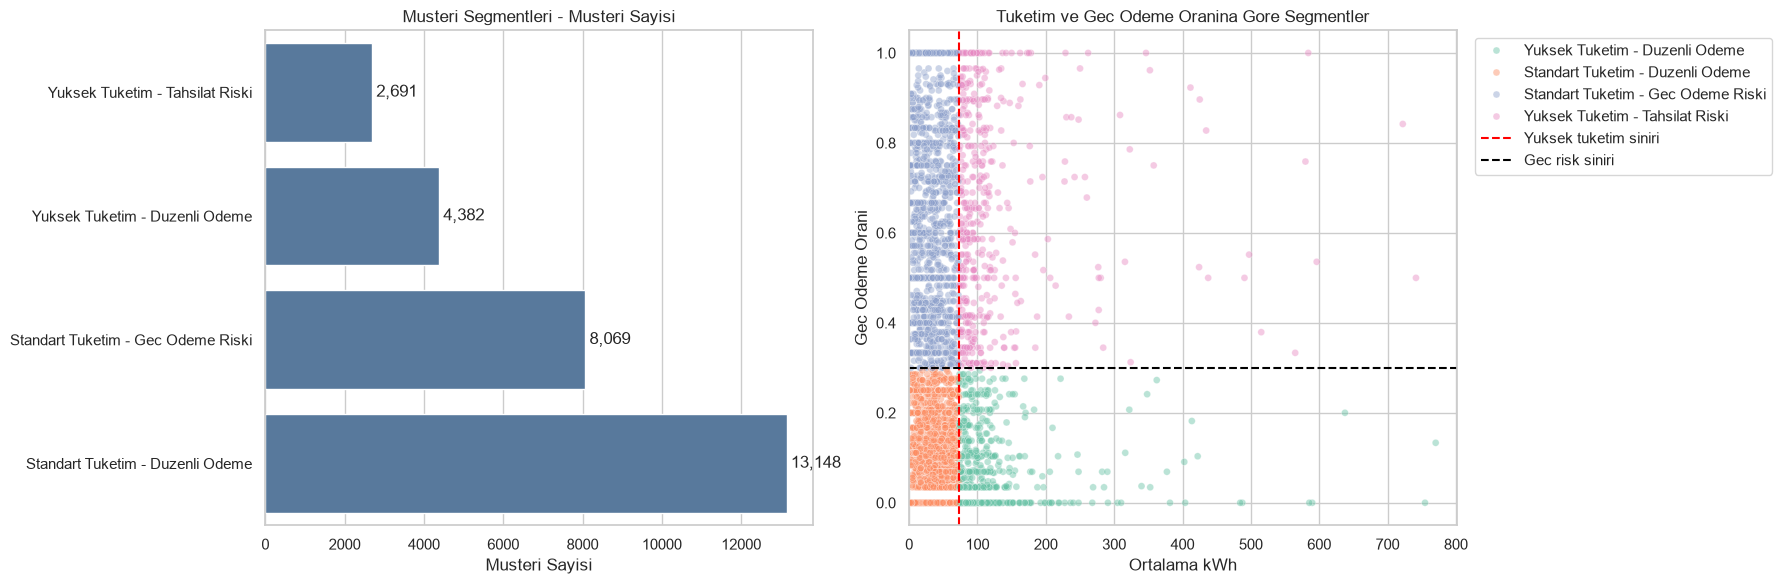

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

segment_counts = musteri_segment["segment"].value_counts().sort_values(ascending=True)
sns.barplot(x=segment_counts.values, y=segment_counts.index, ax=axes[0], color="#4C78A8")
axes[0].set_title("Musteri Segmentleri - Musteri Sayisi")
axes[0].set_xlabel("Musteri Sayisi")
axes[0].set_ylabel("")
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3)

sns.scatterplot(
    data=musteri_segment.sample(n=min(5000, len(musteri_segment)), random_state=42),
    x="ortalama_kwh",
    y="gec_oran",
    hue="segment",
    alpha=0.45,
    s=25,
    ax=axes[1],
)
axes[1].axvline(yuksek_tuketim_sinir, color="red", linestyle="--", label="Yuksek tuketim siniri")
axes[1].axhline(gec_risk_sinir, color="black", linestyle="--", label="Gec risk siniri")
axes[1].set_xlim(0, musteri_segment["ortalama_kwh"].quantile(0.99))
axes[1].set_title("Tuketim ve Gec Odeme Oranina Gore Segmentler")
axes[1].set_xlabel("Ortalama kWh")
axes[1].set_ylabel("Gec Odeme Orani")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "musteri_segmentasyonu.png", dpi=150, bbox_inches="tight")
plt.show()


### Bulgular

- Segmentasyon, tuketim seviyesi ile gec odeme davranisini birlikte kullanarak daha aksiyon alinabilir musteri gruplari olusturur.
- **Standart Tuketim - Duzenli Odeme:** Ana musteri tabanidir. Bu grupta maliyetli manuel takip yerine otomatik ve dusuk maliyetli iletisim yeterlidir.
- **Yuksek Tuketim - Duzenli Odeme:** Gelir etkisi yuksek, tahsilat riski dusuk degerli musteri grubudur. Bu grup icin deneyim ve sadakat odakli yaklasim daha anlamlidir.
- **Standart Tuketim - Gec Odeme Riski:** Tutar etkisi sinirli olabilir ama adet olarak buyurse operasyonel takip maliyeti yaratir. Otomatik hatirlatma ve dijital odeme yonlendirmesi uygundur.
- **Yuksek Tuketim - Tahsilat Riski:** En kritik segmenttir. Hem gelir etkisi hem gec odeme riski yuksek oldugu icin nakit akisi acisindan oncelikli izlenmelidir.

### Segment Bazli Aksiyon Tasarimi

| Segment | Risk | Firsat | Onerilen Aksiyon |
|---|---:|---:|---|
| Standart Tuketim - Duzenli Odeme | Dusuk | Operasyon maliyetini azaltma | Self-servis kanal ve standart bilgilendirme |
| Yuksek Tuketim - Duzenli Odeme | Dusuk-Orta | Gelir koruma | Memnuniyet, sadakat, oncelikli destek |
| Standart Tuketim - Gec Odeme Riski | Orta | Davranis iyilestirme | Otomatik hatirlatma, kolay odeme linki |
| Yuksek Tuketim - Tahsilat Riski | Yuksek | Nakit akisi koruma | Erken uyari, proaktif arama, odeme plani |

### Is Onerileri

- Segmentler aylik olarak yeniden hesaplanmali; segment degistiren musteriler erken uyari listesine alinmalidir.
- Yuksek tuketimli ve gec odeme riski olan musteriler icin standart SMS yeterli olmayabilir; bu gruba proaktif musteri temsilcisi veya odeme plani yaklasimi uygulanabilir.
- Duzenli odeme yapan yuksek tuketimli musteriler icin tahsilat baskisi yerine memnuniyet ve kanal deneyimi iyilestirmesi oncelikli olmalidir.
- Standart tuketimli gec odeme riski icin dusuk maliyetli otomasyon uygundur: son odeme tarihinden once hatirlatma, son gun bildirim, gecikme sonrasi dijital odeme linki.


## 5. Gorev 3 - Tahsilat Performansi Analizi

### Problem Tanimi

Tahsilat surecinde hangi odeme davranislari risk olusturuyor ve tahsilat performansi nasil iyilestirilebilir?

### Hipotez

Genel zamaninda odeme orani yuksek olsa da gec odeme bulunan kayitlar belirli musteri ve hesap sinifi gruplarinda yogunlasabilir. Bu gruplar hedefli aksiyonlarla daha iyi yonetilebilir.


In [7]:
toplam_fatura_kaydi = len(df_tahsilat_1_clean)
zamaninda_kayit_sayisi = df_tahsilat_1_clean["zamaninda_kayit"].sum()
gec_kayit_sayisi = df_tahsilat_1_clean["gec_kayit"].sum()

odeme_performans = pd.DataFrame({
    "Gosterge": ["Zamaninda veya Erken Odeme", "Gec Odeme"],
    "Kayit Sayisi": [zamaninda_kayit_sayisi, gec_kayit_sayisi],
    "Oran (%)": [
        zamaninda_kayit_sayisi / toplam_fatura_kaydi * 100,
        gec_kayit_sayisi / toplam_fatura_kaydi * 100,
    ],
}).round(2)

display(odeme_performans)

gec_hesap_sinifi = (
    df_tahsilat_1_clean[df_tahsilat_1_clean["gec_kayit"]]
    [hesap_sinifi_col_tahsilat1]
    .value_counts()
    .head(10)
    .rename_axis("Hesap Sinifi")
    .reset_index(name="Gec Odeme Kaydi")
)

display(gec_hesap_sinifi)


,Gosterge,Kayit Sayisi,Oran (%)
0,Zamaninda veya Erken Odeme,789588,86.05
1,Gec Odeme,249487,27.19


,Hesap Sinifi,Gec Odeme Kaydi
0,Mesken,212952
1,Ticari Faaliyet - Yazıhane,21782
2,Tarımsal Faaliyetler (Şahıs),2622
3,Şantiye ve Geçici Aboneler,2480
4,İbadethane Isıtma/Soğutma/Lojman,1699
5,İbadethane Aydınlatma,1113
6,1 SAYILI CETVELDE YER ALAN KAMU İDARESİ,1107
7,"Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)",867
8,Belediye,789
9,Köy İçme Suyu Temini ve Dağıtımı Tesisi,736


### Analiz ve Gorseller

![Odeme Zamanlamasi Paneli](../outputs/figures/odeme_zamanlamasi_panel.png)

![Iliski Analizi](../outputs/figures/iliski_analizi_scatter_korelasyon.png)


### Bulgular

- Fatura kayitlarinin yaklasik %86'sinda zamaninda veya erken odeme bulunmaktadir. Bu, genel tahsilat davranisinin guclu oldugunu ve musterilerin buyuk kisminda odeme disiplininin var oldugunu gosterir.
- Gec odeme bulunan kayit orani yaklasik %27.2'dir. Bu oran, zamaninda odeme oraninin yuksek olmasina ragmen gec odemenin ihmal edilemeyecek buyuklukte oldugunu gosterir.
- Bu iki oran birlikte okunmalidir; cunku kismi odemeler nedeniyle ayni fatura kaydinda hem zamaninda hem gec odeme bulunabilir. Bu durum klasik "odedi/odemedi" bakisindan daha karmasik bir tahsilat davranisi oldugunu gosterir.
- Gec odeme davranisi hesap sinifi ve musteri segmenti bazinda takip edilmelidir. Genel oranlar iyi gorunse bile risk belirli segmentlerde yogunlasabilir.
- Gec odeme kayit sayisinda Mesken grubunun en ustte gorunmesi, bu grubun mutlaka en riskli grup oldugu anlamina gelmez. Mesken kayit hacmi cok yuksek oldugu icin adet bazinda dogal olarak one cikabilir. Bu nedenle hesap siniflari hem gec odeme kayit sayisi hem de kendi icindeki gec odeme orani ile birlikte izlenmelidir.
- Tuketim ile fatura tutari arasinda pozitif iliski beklenir; ancak tahsilat riski yalnizca tuketimden okunamaz. Tuketim, hesap sinifi, gec odeme orani ve gec tutar birlikte ele alinmalidir.

### Tahsilat Stratejisi

- **Erken donem:** Son odeme tarihinden once nazik hatirlatma. Hedef: standart gecikmeleri azaltmak.
- **Son gun:** Dijital odeme linki ve kanal yonlendirmesi. Hedef: odeme surtunmesini azaltmak.
- **Gecikme sonrasi:** Risk segmentine gore farkli aksiyon. Standart riskte otomatik bildirim, yuksek tuketimli riskte proaktif arama.
- **Tekrarlayan gecikme:** Musteri bazli risk skoru ve odeme plani degerlendirmesi.

### Is Onerileri

- Gec odeme riski olan segmentlere son odeme tarihinden once otomatik hatirlatma yapilmalidir.
- Yuksek tuketimli ve gec odeme riski olan musteriler icin erken uyari listesi olusturulmalidir.
- Tahsilat kanallari aylik izlenmeli; banka/sube yogunluklari operasyon planlamasinda kullanilmalidir.
- Kismi odeme davranisi olan musteriler ayrica takip edilmeli; bu musteriler icin taksitlendirme veya odeme plani secenekleri degerlendirilebilir.
- Gec odeme sadece tahsilat problemi olarak degil, musteri deneyimi problemi olarak da ele alinmalidir: odeme kanali, bildirim zamanlamasi ve fatura anlasilirligi birlikte iyilestirilmelidir.


## 6. Genel Sonuc ve Aksiyon Plani

### Genel Sonuc

Bu case study, elektrik tuketimi ve tahsilat davranisinin tek bir metrikle aciklanamayacagini gostermektedir. Ilce buyuklugu, hesap sinifi kompozisyonu, mevsimsellik, tuketim seviyesi ve odeme zamanlamasi birlikte degerlendirilmelidir.

En onemli mesaj sudur: **Ayni tahsilat stratejisi her musteri ve her ilce icin ayni etkiyi yaratmaz.** Veri, farkli davranis gruplarina farkli aksiyon tasarlanmasi gerektigini gostermektedir.

### Oncelikli Aksiyonlar

1. **Ilce bazli takip:** Gumushacikoy hacim olarak buyuk oldugu icin operasyonel takipte oncelikli ele alinmalidir.
2. **Segment bazli tahsilat:** Yuksek tuketimli ve gec odeme riski olan musteriler erken uyari listesine alinmalidir.
3. **Mevsimsel planlama:** Yaz aylarinda artan tuketim icin talep, tahsilat ve saha kapasitesi onceden planlanmalidir.
4. **Hesap sinifi odakli analiz:** Sanayi, tarimsal faaliyet, altyapi ve uretici gruplari yuksek tuketim etkisi nedeniyle ayri izlenmelidir.
5. **Odeme davranisi izleme:** Zamaninda odeme ve gec odeme oranlari kayit bazinda aylik takip edilmeli, kismi odeme davranisi ayrica raporlanmalidir.
6. **Veri kalitesi izleme:** Negatif, sifir ve aykiri kWh degerleri silinmeden once operasyonel aciklamalariyla birlikte isaretlenmelidir.

### 30-60-90 Gunluk Yol Haritasi

| Donem | Aksiyon | Beklenen Etki |
|---|---|---|
| Ilk 30 gun | Segmentleri aylik rapora ekle, gec odeme risk listesini olustur | Riskli musterilerin gorunur hale gelmesi |
| 60 gun | Hatirlatma ve dijital odeme linki akisini segment bazli test et | Gec odeme oraninda dusus |
| 90 gun | Ilce + hesap sinifi + mevsimsellik dashboardu kur | Operasyon ve nakit akisi planlamasinin iyilesmesi |

### Sonraki Adimlar

- Segmentlerin aylik degisimini izleyen bir dashboard kurulabilir.
- Gec odeme tahmini icin basit bir risk skoru gelistirilebilir.
- Tahsilat kanali performansi sube/banka bazinda zaman serisi olarak izlenebilir.
- Yuksek tuketim ve aykiri degerler icin hesap sinifi bazli esik degerler tanimlanabilir.
